# Eksperyment Imagenette - Porównanie Embeddingów z Treningiem na Wagach Places365
Ten notatnik wykonuje kurację danych poprzez hierarchical k-means na ekstrakcji cech z ResNet50 (Places365) oraz DINO.
**Kluczowa zmiana:** Ewaluacja podzbiorów (Linear Probing) dokonywana jest na zamrożonych wagach modelu ResNet50-Places365, a nie standardowego ResNet50 (ImageNet).

In [1]:
import os
import sys
import subprocess
import random
import warnings
import urllib.request
import tarfile
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


### Konfiguracja notebooka

In [2]:
# --- SETUP ----
DEBUG = False
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", message=".*Torch was not compiled with flash attention.*")
# mps: macOS GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
SEED = 45390
PROJECT_PATH = os.path.abspath(os.path.join("."))
print(f"Device: {device}")

# --- CONFIG ---
_PLACES_365_WEIGHTS_URL = (
    "http://places2.csail.mit.edu/models_places365/{model_id}_places365.pth.tar"
)
CLUSTERING_METHODS = ["hierarchical_sampling"]

# DATA CONFIG — zmień tylko DATASET żeby przełączyć dataset
DATASET = "imagenette"  # "imagenette" | "skewed_imagenet1k" | "places365"

DATASET_CONFIGS = {
    "imagenette": {
        "url":            "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz",
        "filename":       "imagenette.tgz",
        "extract_mode":   "r:gz",
        "dir_name":       "imagenette2-320",
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       None,   # brak osobnego test setu
        "split_val_test": True,
        "num_classes":    10,
    },
    "skewed_imagenet1k": {
        "url":            None,   # brak pobierania, dataset musi być na dysku
        "filename":       None,
        "extract_mode":   None,
        "dir_name":       "skewed_imagenet1k",  # zmień jeśli folder jest inaczej nazwany
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       "test",
        "split_val_test": False,
        "num_classes":    20,
    },
    "places365": {
        "url":            "http://data.csail.mit.edu/places/places365/val_256.tar",
        "filename":       "places365_val.tar",
        "extract_mode":   "r:",
        "dir_name":       "places365_val",
        "train_dir":      "train",
        "val_dir":        "val",
        "test_dir":       None,
        "split_val_test": True,
        "num_classes":    365,
    },
}

DATA_ROOT = os.path.join(PROJECT_PATH,'data')  # gdzie trzymamy datasety

# --- pochodne, nie zmieniaj ---
_cfg      = DATASET_CONFIGS[DATASET]
NUM_CLASSES = _cfg["num_classes"]
DATA_PATH   = os.path.join(DATA_ROOT, _cfg["dir_name"])

print(f"Dataset : {DATASET}")
print(f"Klasy   : {NUM_CLASSES}")
print(f"Ścieżka : {DATA_PATH}")

# REPOSITORY FROM PAPER
REPO_NAME = "ssl-data-curation"
REPO_URL = "https://github.com/facebookresearch/ssl-data-curation.git"
REPO_PATH = os.path.join(PROJECT_PATH, f"{REPO_NAME}/")

# TRAINING PARAMETERS
MAX_EPOCHS = 50 
EARLY_STOPPING_PATIENCE = 5 
lr = 1e-2
batch_size = 64

# HIERARCHICAL SAMPLING PARAMETERS
N_CLUSTERS_DINO=[100, 10]
N_LEVELS_DINO=2
SAMPLE_SIZES_DINO=[65, 650]

N_CLUSTERS_RESNET=[100, 10]
N_LEVELS_RESNET=2
SAMPLE_SIZES_RESNET=[65, 650]

# OTHER CLASTERING METHODS PARAMETERS
N_CLUSTERS_KMEANS = 100
EPS_DBSCAN = 0.5
MIN_SAMPLES_DBSCAN = 5 

Device: cpu
Dataset : imagenette
Klasy   : 10
Ścieżka : c:\Users\Siema\Documents\wb2_projekt2\WB2_Project\data\imagenette2-320


In [3]:
def setup_repo():
    if not os.path.exists(REPO_PATH):
        print(f"--- Cloning repository {REPO_NAME}... ---")
        subprocess.run(["git", "clone", REPO_URL], check=True)

    src_path = os.path.join(REPO_PATH, "src")
    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)
    print("--- Repository paths configured ---")
    
setup_repo()
from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg
from src import hierarchical_sampling as hs
from other_clustering_methods import kmeans_sampling, dbscan_sampling

--- Repository paths configured ---


### Przygotowanie plików z wybranym zbiorem danych

In [4]:
def _reorganize_places365(data_path: str) -> None:
    """Układa val-set Places365 w strukturę ImageFolder."""
    map_url  = "https://raw.githubusercontent.com/CSAILVision/places365/master/places365_val.txt"
    map_path = os.path.join(data_path, "val_map.txt")
    urllib.request.urlretrieve(map_url, map_path)
    with open(map_path) as f:
        for line in f:
            img_name, class_idx = line.strip().split()
            class_dir = os.path.join(data_path, "train", class_idx)
            os.makedirs(class_dir, exist_ok=True)
            src = os.path.join(data_path, img_name)
            if os.path.exists(src):
                shutil.move(src, os.path.join(class_dir, os.path.basename(img_name)))


def prepare_data(cfg: dict, data_root: str = DATA_ROOT) -> None:
    data_path = os.path.join(data_root, cfg["dir_name"])
    if not os.path.exists(DATA_ROOT):
        os.makedirs(DATA_ROOT,exist_ok=True)

    if os.path.exists(data_path):
        print(f"Dataset już istnieje: {data_path}")
        return

    if cfg["url"] is None:
        raise FileNotFoundError(
            f"Dataset '{cfg['dir_name']}' nie istnieje w {data_root} "
            "i nie ma skonfigurowanego URL — umieść go ręcznie."
        )

    archive_path = os.path.join(data_root, cfg["filename"])
    if not os.path.exists(archive_path):
        print(f"Pobieranie {cfg['filename']}…")
        urllib.request.urlretrieve(cfg["url"], archive_path)

    print(f"Rozpakowywanie {cfg['filename']}…")
    with tarfile.open(archive_path, cfg["extract_mode"]) as tar:
        tar.extractall(path=data_root)

    if DATASET == "places365":
        print("Reorganizacja Places365…")
        _reorganize_places365(data_path)

    print(f"Dataset gotowy: {data_path}")


prepare_data(_cfg)

Dataset już istnieje: c:\Users\Siema\Documents\wb2_projekt2\WB2_Project\data\imagenette2-320


### Wczytanie wybranego datasetu, train/test/validation split

In [5]:
# ----------------- TRANSFORMS & DATASETS ----------------------
class ResnetTransform:
    def __init__(self):
        self.transfrom = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __call__(self,img):
        return self.transfrom(img)

class DinoTransform:
    def __init__(self, processor=AutoImageProcessor.from_pretrained('facebook/dinov2-large')):
        self.processor = processor
    def __call__(self, img):
        return self.processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
    
def _split_val_test(base_dataset, seed: int):
    """Dzieli dataset 50/50 (stratified) na val i test."""
    indices = np.arange(len(base_dataset))
    v_idx, t_idx = train_test_split(
        indices, test_size=0.5, stratify=base_dataset.targets, random_state=seed
    )
    return Subset(base_dataset, v_idx), Subset(base_dataset, t_idx)


def load_datasets(cfg: dict, data_path: str, seed: int, batch_size: int = 64):
    """
    Zwraca: train_dataset, train_dataset_dino, val_loader, test_loader
    """
    train_dir = os.path.join(data_path, cfg["train_dir"])
    train_dataset      = datasets.ImageFolder(train_dir, transform=ResnetTransform())
    train_dataset_dino = datasets.ImageFolder(train_dir, transform=DinoTransform())

    if cfg["split_val_test"]:
        val_base = datasets.ImageFolder(
            os.path.join(data_path, cfg["val_dir"]), transform=ResnetTransform()
        )
        val_dataset, test_dataset = _split_val_test(val_base, seed)
    else:
        val_dataset  = datasets.ImageFolder(
            os.path.join(data_path, cfg["val_dir"]),  transform=ResnetTransform()
        )
        test_dataset = datasets.ImageFolder(
            os.path.join(data_path, cfg["test_dir"]), transform=ResnetTransform()
        )

    val_loader  = DataLoader(val_dataset,  batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Train : {len(train_dataset):>6} próbek")
    print(f"Val   : {len(val_dataset):>6} próbek")
    print(f"Test  : {len(test_dataset):>6} próbek")

    return train_dataset, train_dataset_dino, val_loader, test_loader


train_dataset, train_dataset_dino, val_loader, test_loader = load_datasets(
    _cfg, DATA_PATH, SEED, batch_size
)

Train :   9469 próbek
Val   :   1962 próbek
Test  :   1963 próbek


### Funkcje pomocnicze

In [9]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
# ----------------- PLACES365 WEIGHTS LOADER ----------------------
def _load_places_365_state_dict(model_id: str, device: torch.device) -> dict[str, torch.Tensor]:
    checkpoint = torch.hub.load_state_dict_from_url(
        _PLACES_365_WEIGHTS_URL.format(model_id=model_id),
        map_location=device,
    )
    state_dict = checkpoint["state_dict"]
    return {k.replace("module.", ""): v for k, v in state_dict.items()}

def get_places365_eval_model(num_classes, device):
    """
    Tworzy model ResNet50 zainicjowany wagami z Places365, 
    zamraża wagi konwolucyjne i ustawia głowę klasyfikacyjną na podaną liczbę klas.
    """
    model = models.resnet50()
    state_dict = _load_places_365_state_dict("resnet50", device)
    
    model.fc = nn.Linear(model.fc.in_features, 365)
    model.load_state_dict(state_dict)
    
    for params in model.parameters():
        params.requires_grad=False
        
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

# ----------------- EMBEDDING FUNCTIONS ----------------------
def get_dino_embedings(dataset, batch_size=128):
    extractor = AutoModel.from_pretrained('facebook/dinov2-large')
    extractor.eval()
    extractor.to(device)
    all_embedings = []
    with torch.inference_mode(), torch.amp.autocast('cuda'):
        extr_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        for imgs, labels in tqdm(extr_loader, desc="Dino Feature extraction"):
            imgs = imgs.to(device)
            outputs = extractor(imgs)
            embedings = outputs.last_hidden_state[:,0,:]
            all_embedings.append(embedings.cpu())
            
    return torch.cat(all_embedings).to(device)

def get_resnet50_places365_embedings(dataset, batch_size=128):
    extractor = models.resnet50()
    state_dict = _load_places_365_state_dict("resnet50", device)
    extractor.fc = nn.Linear(extractor.fc.in_features, 365)
    extractor.load_state_dict(state_dict)
    extractor.fc = nn.Identity()  # usunięcie głowy do ekstrakcji cech
    extractor.eval().to(device)
    
    all_features = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        feature_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        for imgs, _ in tqdm(feature_loader, desc="Places365 Feature extraction"):
            feat = extractor(imgs.to(device))
            all_features.append(feat.cpu())            
    return torch.cat(all_features).to(device)

# -------------------- WIZUALIZACJA ----------------------
def plot_training_curve(losses, title="Training Curve"):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='b', label='Train Loss')
    
    plt.title(f"{title} - Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


### pętla treningowa

In [7]:
# ----------------- TRAINING FUNCTION ----------------------
def train_model(model, criterion, optimizer, train_loader, val_dataloader, test_dataloader, device, title, max_epochs=MAX_EPOCHS,
                 epoch_tqdm=False, loader_tqdm=True, early_stopping=True, patience=EARLY_STOPPING_PATIENCE):
    print(f"\n[TRENING] Start: {title}")
    scaler = torch.amp.GradScaler("cuda")
    losses = []

    epoch_progress = range(max_epochs)
    if epoch_tqdm:
        epoch_progress = tqdm(range(max_epochs), desc='Epochs')
    patience_counter=0
    best_val_loss = np.inf
    best_state = model.state_dict()
    best_state = {k:v.clone() for k, v in best_state.items()}
    for epoch in epoch_progress:
        model.train()
        running_loss = 0.0
        loader_progress = train_loader
        if loader_tqdm:
            loader_progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epochs}")
                                   
        for imgs, labels in loader_progress:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
        losses.append(running_loss/len(train_loader))

        if early_stopping:
            model.eval()
            val_loss = 0.0
            with torch.inference_mode():
                for imgs, labels in val_dataloader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                    val_loss += criterion(outputs, labels).item()
            val_loss = val_loss/len(val_dataloader)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict()
                best_state = {k:v.clone() for k, v in best_state.items()}
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

    if early_stopping:
        model.load_state_dict(best_state)
    model.eval()

    accuracy_dict={}
    with torch.inference_mode():
        for loader, label in [(val_dataloader, "Validation"), (test_dataloader, "Test")]:
            correct = 0
            total = 0
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            accuracy_dict[label] = accuracy_dict
            print(f"[RESULT] {title} {label} Accuracy: {accuracy:.2f}%")

    return accuracy_dict["Test"], losses

### Ekstrakcja featurów i tworzenie klastrów do samplingu

In [10]:
print("\n--- Feature extraction and hierarchical k-means (DINO) ---")
set_seed(SEED)
dino_embedings = get_dino_embedings(train_dataset_dino).float()
clusters_dino = hkmg.hierarchical_kmeans_with_resampling(
    data=dino_embedings,                                                                           
    n_clusters=N_CLUSTERS_DINO,
    n_levels=N_LEVELS_DINO,
    sample_sizes=SAMPLE_SIZES_DINO,
    verbose=False,
)
cl_dino = HierarchicalCluster.from_dict(clusters_dino)

print("\n--- Feature extraction and hierarchical k-means (ResNet-Places365) ---")
set_seed(SEED)
resnet_embedings = get_resnet50_places365_embedings(train_dataset).float()
clusters_places = hkmg.hierarchical_kmeans_with_resampling(
    data=resnet_embedings,                                                                           
    n_clusters=N_CLUSTERS_RESNET,
    n_levels=N_LEVELS_RESNET,
    sample_sizes=SAMPLE_SIZES_RESNET,
    verbose=False,
)
cl_places = HierarchicalCluster.from_dict(clusters_places)


--- Feature extraction and hierarchical k-means (DINO) ---


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

c:\Users\Siema\Documents\wb2_projekt2\WB2_Project\.venv\lib\site-packages\torch\amp\autocast_mode.py:265: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Dino Feature extraction:   0%|          | 0/74 [00:00<?, ?it/s]

KeyboardInterrupt: 

Experimenting with feature extraction for sampling | Dino vs Resnet50-Places365
Ewaluacja (Linear Probing) na wagach PLACES365
Subset size: 946 / 9469 (10.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1812.81it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 11
[RESULT] Dino features | Validation Accuracy: 83.44%
[RESULT] Dino features | Test Accuracy: 83.79%


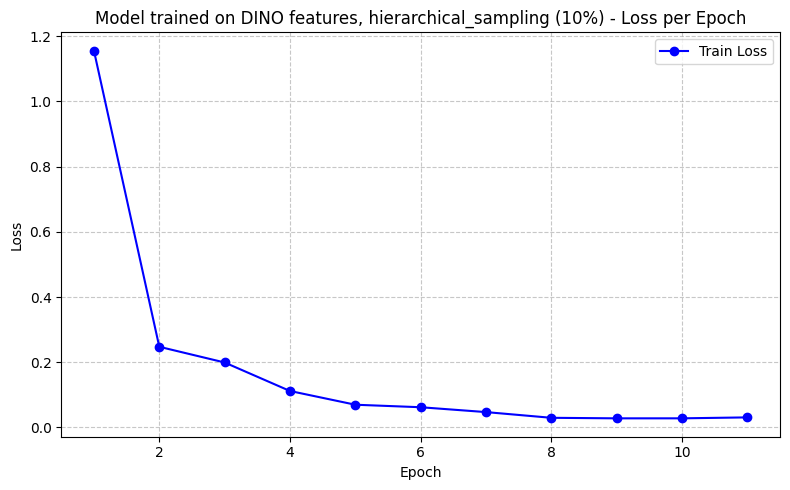


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1999.95it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 17
[RESULT] Resnet-Places365 features | Validation Accuracy: 90.68%
[RESULT] Resnet-Places365 features | Test Accuracy: 90.01%


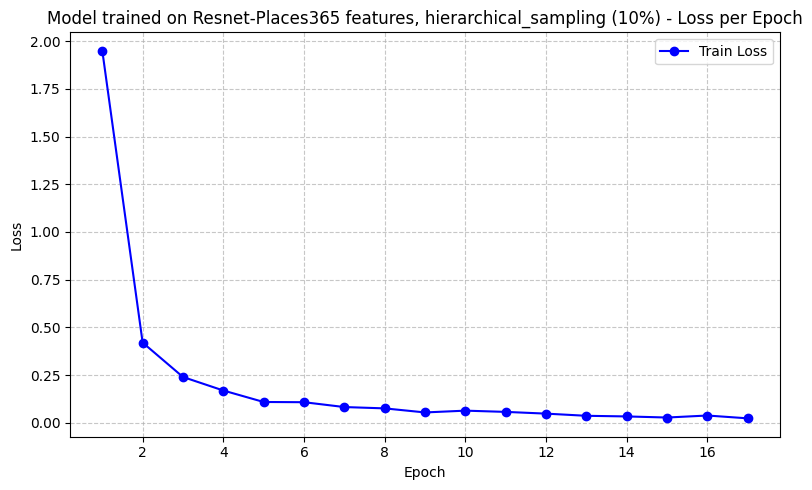


------------------------------------------------------------

Subset size: 1893 / 9469 (20.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2096.73it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 10
[RESULT] Dino features | Validation Accuracy: 88.18%
[RESULT] Dino features | Test Accuracy: 87.67%


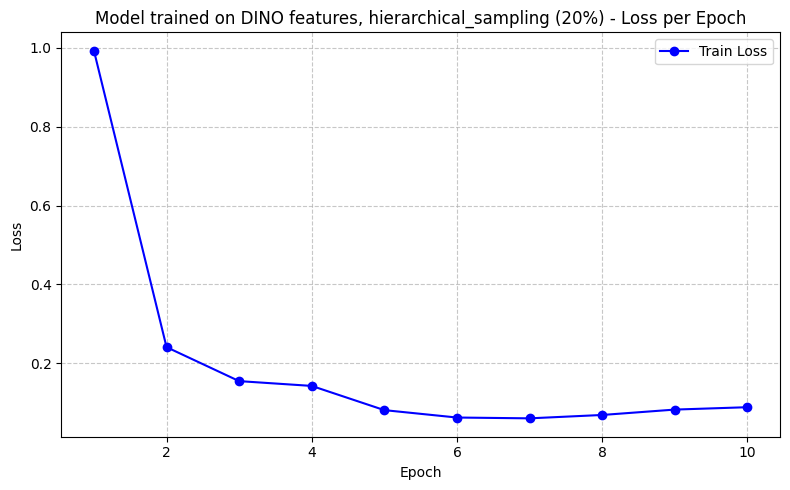


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1604.92it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 11
[RESULT] Resnet-Places365 features | Validation Accuracy: 91.49%
[RESULT] Resnet-Places365 features | Test Accuracy: 90.62%


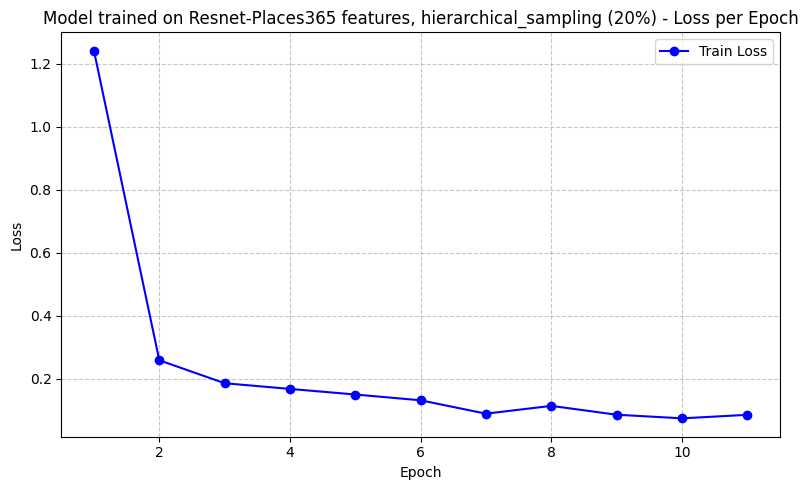


------------------------------------------------------------

Subset size: 2840 / 9469 (30.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2005.79it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 8
[RESULT] Dino features | Validation Accuracy: 85.18%
[RESULT] Dino features | Test Accuracy: 86.85%


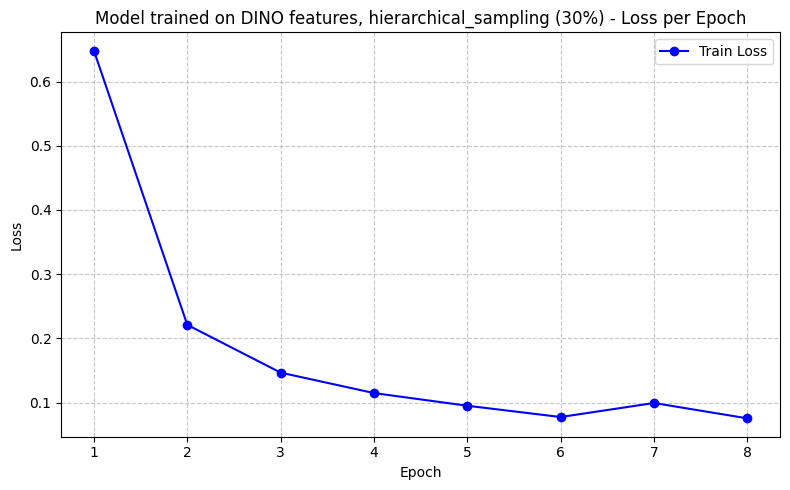


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2004.73it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 9
[RESULT] Resnet-Places365 features | Validation Accuracy: 92.31%
[RESULT] Resnet-Places365 features | Test Accuracy: 91.74%


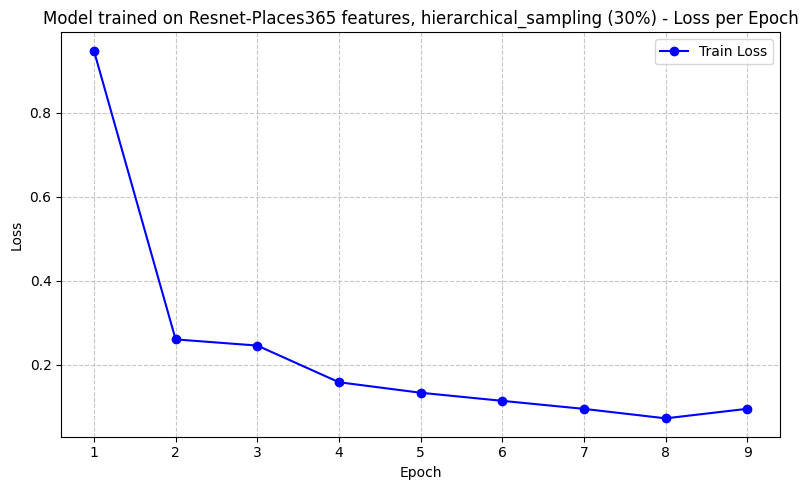


------------------------------------------------------------

Subset size: 3787 / 9469 (40.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1822.26it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 9
[RESULT] Dino features | Validation Accuracy: 87.93%
[RESULT] Dino features | Test Accuracy: 89.35%


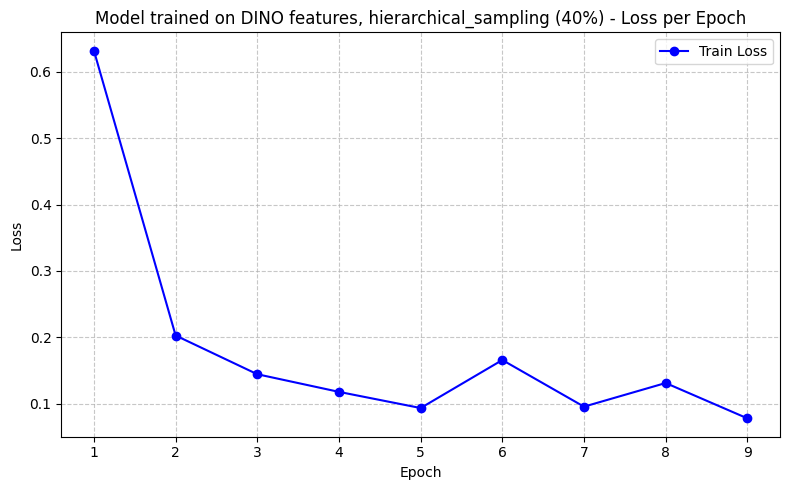


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1525.92it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 9
[RESULT] Resnet-Places365 features | Validation Accuracy: 92.10%
[RESULT] Resnet-Places365 features | Test Accuracy: 91.44%


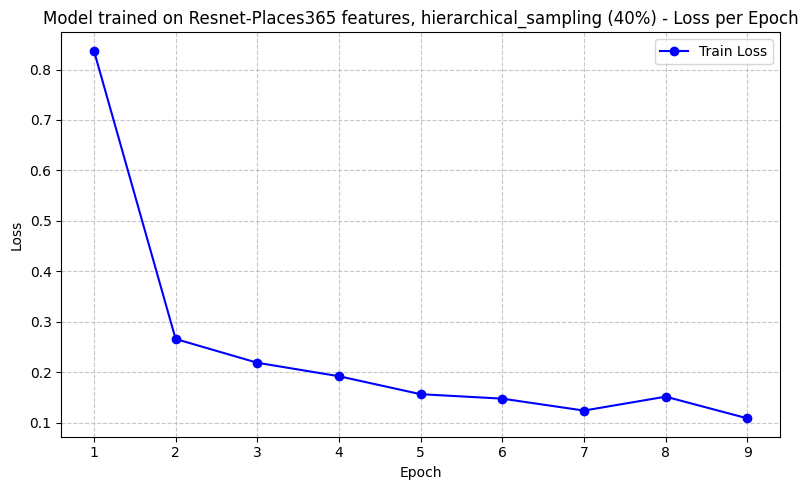


------------------------------------------------------------

Subset size: 4734 / 9469 (50.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1978.73it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 7
[RESULT] Dino features | Validation Accuracy: 91.24%
[RESULT] Dino features | Test Accuracy: 91.54%


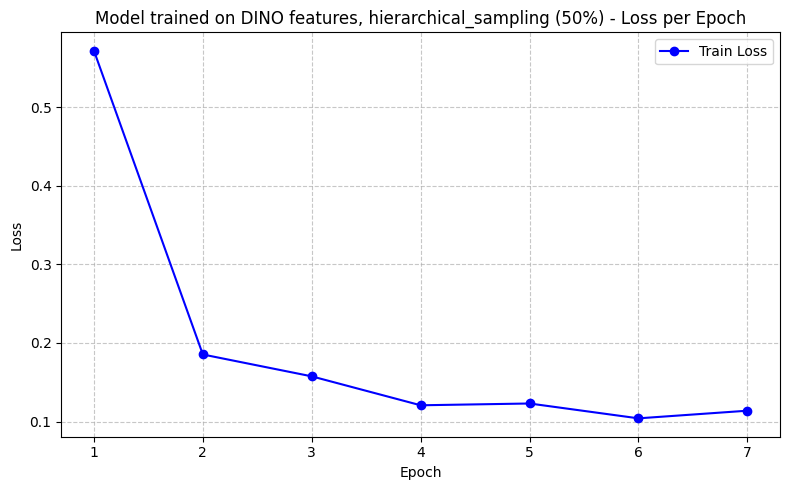


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2002.15it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 9
[RESULT] Resnet-Places365 features | Validation Accuracy: 91.59%
[RESULT] Resnet-Places365 features | Test Accuracy: 91.95%


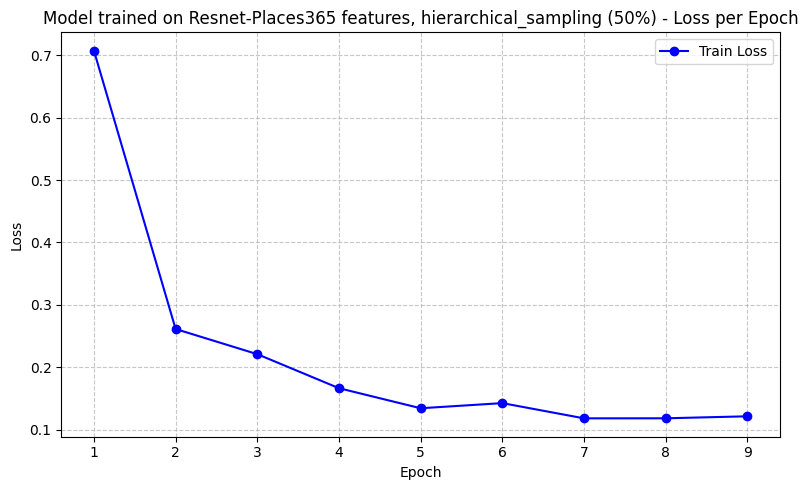


------------------------------------------------------------

Subset size: 5681 / 9469 (60.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2918.39it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 7
[RESULT] Dino features | Validation Accuracy: 89.30%
[RESULT] Dino features | Test Accuracy: 90.57%


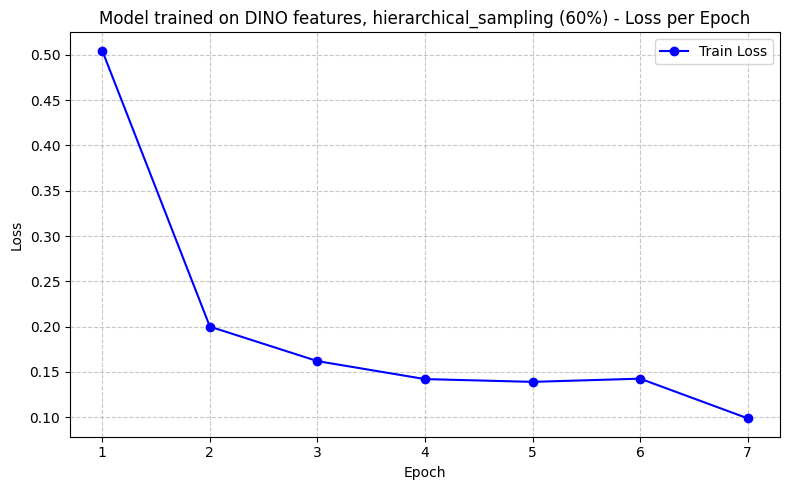


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1975.56it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 6
[RESULT] Resnet-Places365 features | Validation Accuracy: 92.21%
[RESULT] Resnet-Places365 features | Test Accuracy: 92.25%


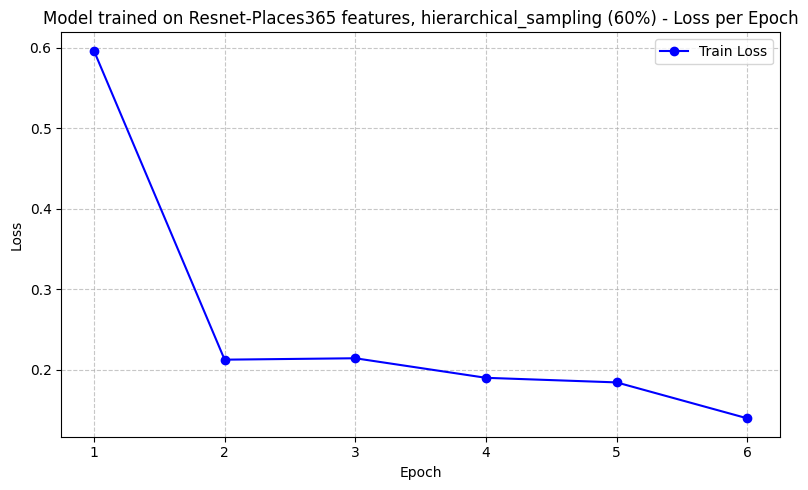


------------------------------------------------------------

Subset size: 6628 / 9469 (70.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2287.97it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 7
[RESULT] Dino features | Validation Accuracy: 91.80%
[RESULT] Dino features | Test Accuracy: 92.10%


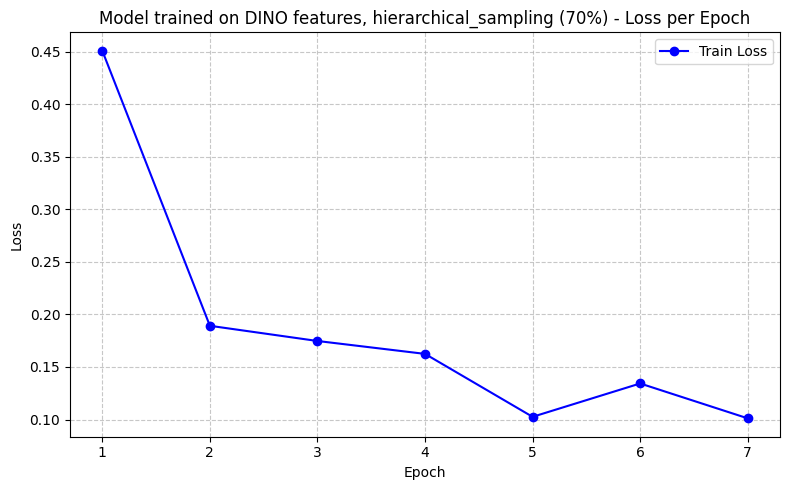


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2982.09it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 9
[RESULT] Resnet-Places365 features | Validation Accuracy: 92.26%
[RESULT] Resnet-Places365 features | Test Accuracy: 92.92%


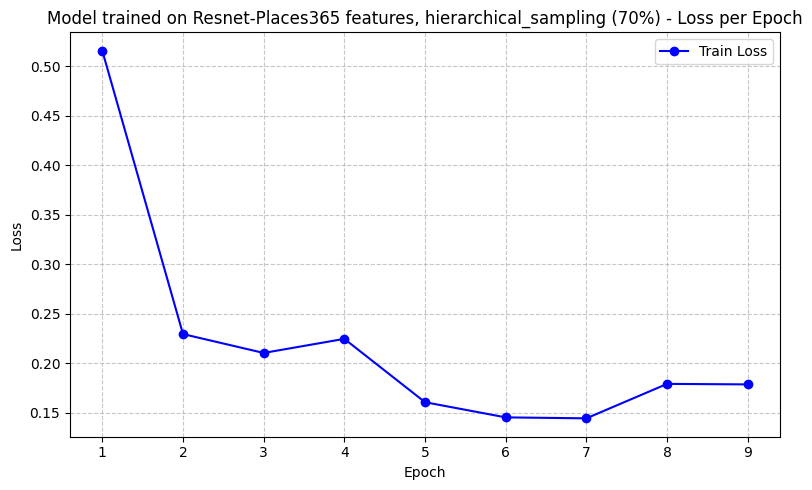


------------------------------------------------------------

Subset size: 7575 / 9469 (80.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2341.22it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 6
[RESULT] Dino features | Validation Accuracy: 87.93%
[RESULT] Dino features | Test Accuracy: 87.05%


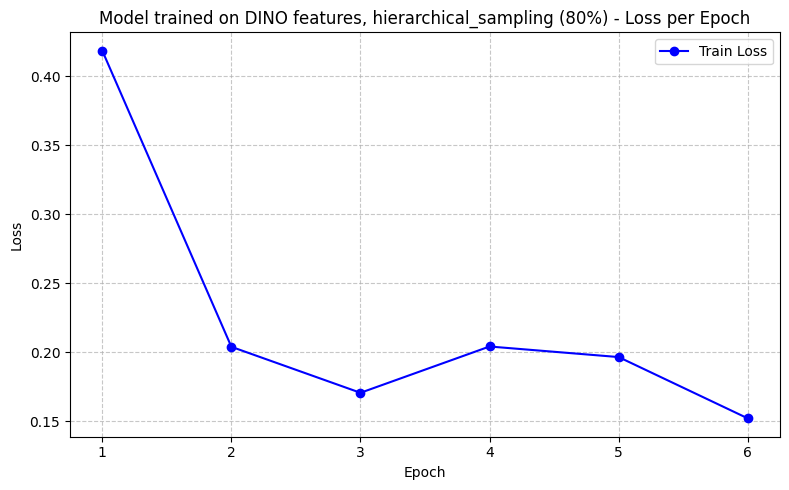


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2262.18it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
print("Experimenting with feature extraction for sampling | Dino vs Resnet50-Places365")
print("Ewaluacja (Linear Probing) na wagach PLACES365")
print("="*60)


percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_embedings = pd.DataFrame(columns=["clustering_method","embedings", "percentage", "accuracy", "losses"])
sampling_embedings = pd.DataFrame(columns=["clustering_method","embedings", "subset"])
for clustering_method in CLUSTERING_METHODS:
    for p in percentages:
        label = f"{int(p * 100)}%"
        target_size = int(len(train_dataset) * p)
        print(f"Subset size: {target_size} / {len(train_dataset)} ({p*100}%)")
        print()
        
        # -------------- trening modelu (LP, sampling z DINO) --------------------
        embedings_name ="Dino"
        if p < 1.0:
            if clustering_method == "hierarchical_sampling":
                idx = hs.hierarchical_sampling(cl_dino, target_size=target_size)
            elif clustering_method == "kmeans":
                idx = kmeans_sampling(dino_embedings, target_size=target_size, n_clusters=100)
            elif clustering_method == "dbscan":
                idx = dbscan_sampling(dino_embedings, target_size=target_size, eps=0.5, min_samples=5)
            else:
                raise ValueError(f"Unknown clustering method: {clustering_method}")
            
            current_ds = Subset(train_dataset, idx)
        else:
            current_ds = train_dataset
        
        new_row = pd.DataFrame({
            "clustering_method":[clustering_method],
            'embedings':[embedings_name],
            "subset":[current_ds]
        })
        sampling_embedings = pd.concat([sampling_embedings,new_row],axis=0)

        set_seed(SEED)
        # TWORZYMY MODEL RESNET50 Z WAGAMI PLACES365 DO EWALUACJI!
        model = get_places365_eval_model(NUM_CLASSES, device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        acc, losses = train_model(model, criterion, optimizer,
                                DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                        generator=torch.Generator().manual_seed(SEED)),
                                test_loader, val_loader, device,
                                "Dino features |",
                                max_epochs=MAX_EPOCHS, early_stopping=True, patience=EARLY_STOPPING_PATIENCE,
                                epoch_tqdm=True, loader_tqdm=False
                                )

        plot_training_curve(losses, title=f"Model trained on DINO features, {clustering_method} ({p*100:.0f}%)")
        results_embedings.loc[len(results_embedings),] = {"clustering_method":clustering_method,'embedings':embedings_name, "percentage":label, "accuracy":acc, "losses":losses}
        print()
        
        # -------------- trening modelu (LP, sampling z Resnet-Places365) --------------------
        embedings_name ="Resnet-Places365"
        if p < 1.0:
            if clustering_method == "hierarchical_sampling":
                idx = hs.hierarchical_sampling(cl_places, target_size=target_size)
            elif clustering_method == "kmeans":
                idx = kmeans_sampling(resnet_embedings, target_size=target_size, n_clusters=100)
            elif clustering_method == "dbscan":
                idx = dbscan_sampling(resnet_embedings, target_size=target_size, eps=0.5, min_samples=5)
            else:
                raise ValueError(f"Unknown clustering method: {clustering_method}")
            current_ds = Subset(train_dataset, idx)
        else:
            current_ds = train_dataset

        new_row = pd.DataFrame({
            "clustering_method":[clustering_method],
            'embedings':[embedings_name],
            "subset":[current_ds]
        })
        sampling_embedings = pd.concat([sampling_embedings,new_row],axis=0)

        set_seed(SEED)
        # TWORZYMY MODEL RESNET50 Z WAGAMI PLACES365 DO EWALUACJI!
        model = get_places365_eval_model(NUM_CLASSES, device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr = lr)
        acc, losses= train_model(model, criterion, optimizer,
                                DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                        generator=torch.Generator().manual_seed(SEED)),
                                test_loader, val_loader, device,
                                "Resnet-Places365 features |",
                                max_epochs=MAX_EPOCHS, early_stopping=True, patience=EARLY_STOPPING_PATIENCE,
                                epoch_tqdm=True, loader_tqdm=False
                                )
        plot_training_curve(losses, title=f"Model trained on Resnet-Places365 features, {clustering_method} ({p*100:.0f}%)")
        results_embedings.loc[len(results_embedings),] = {"clustering_method":clustering_method,'embedings':embedings_name, "percentage":label, "accuracy":acc, "losses":losses}
        print()
        print("-"*60)
        print()

# save results to pkl for later evaluation and plotting
results_embedings.to_pickle("experiment_results.pkl")

# can later be loaded with:
# loaded_results = pd.read_pickle("experiment_results.pkl") --- IGNORE ---

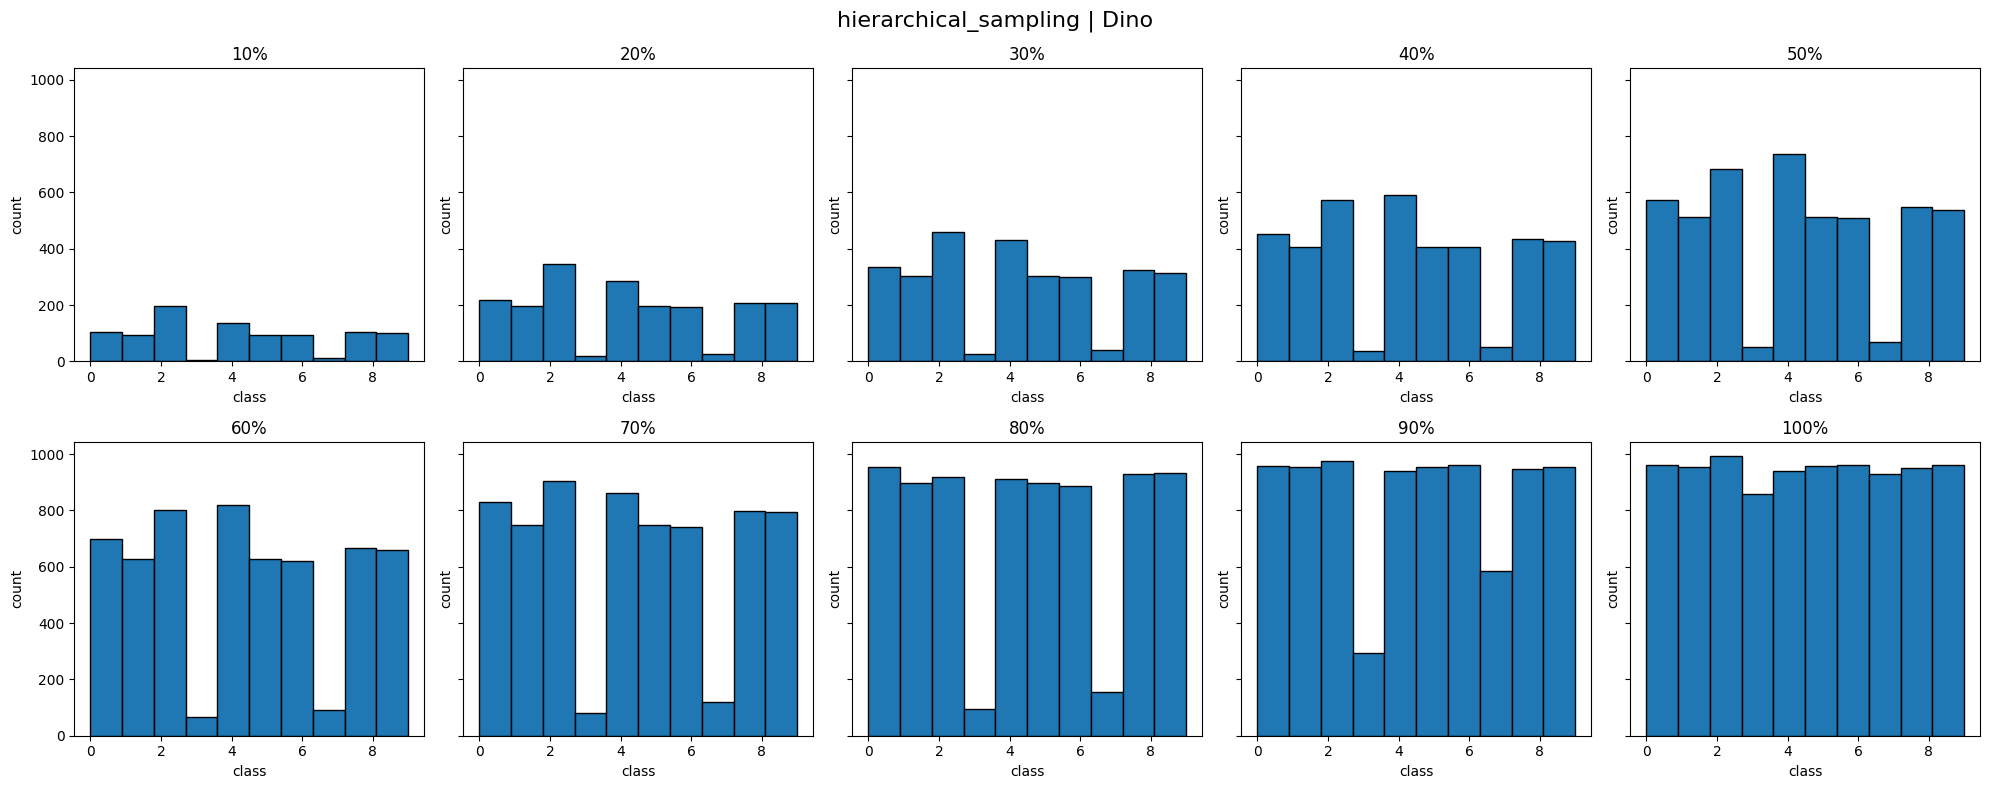

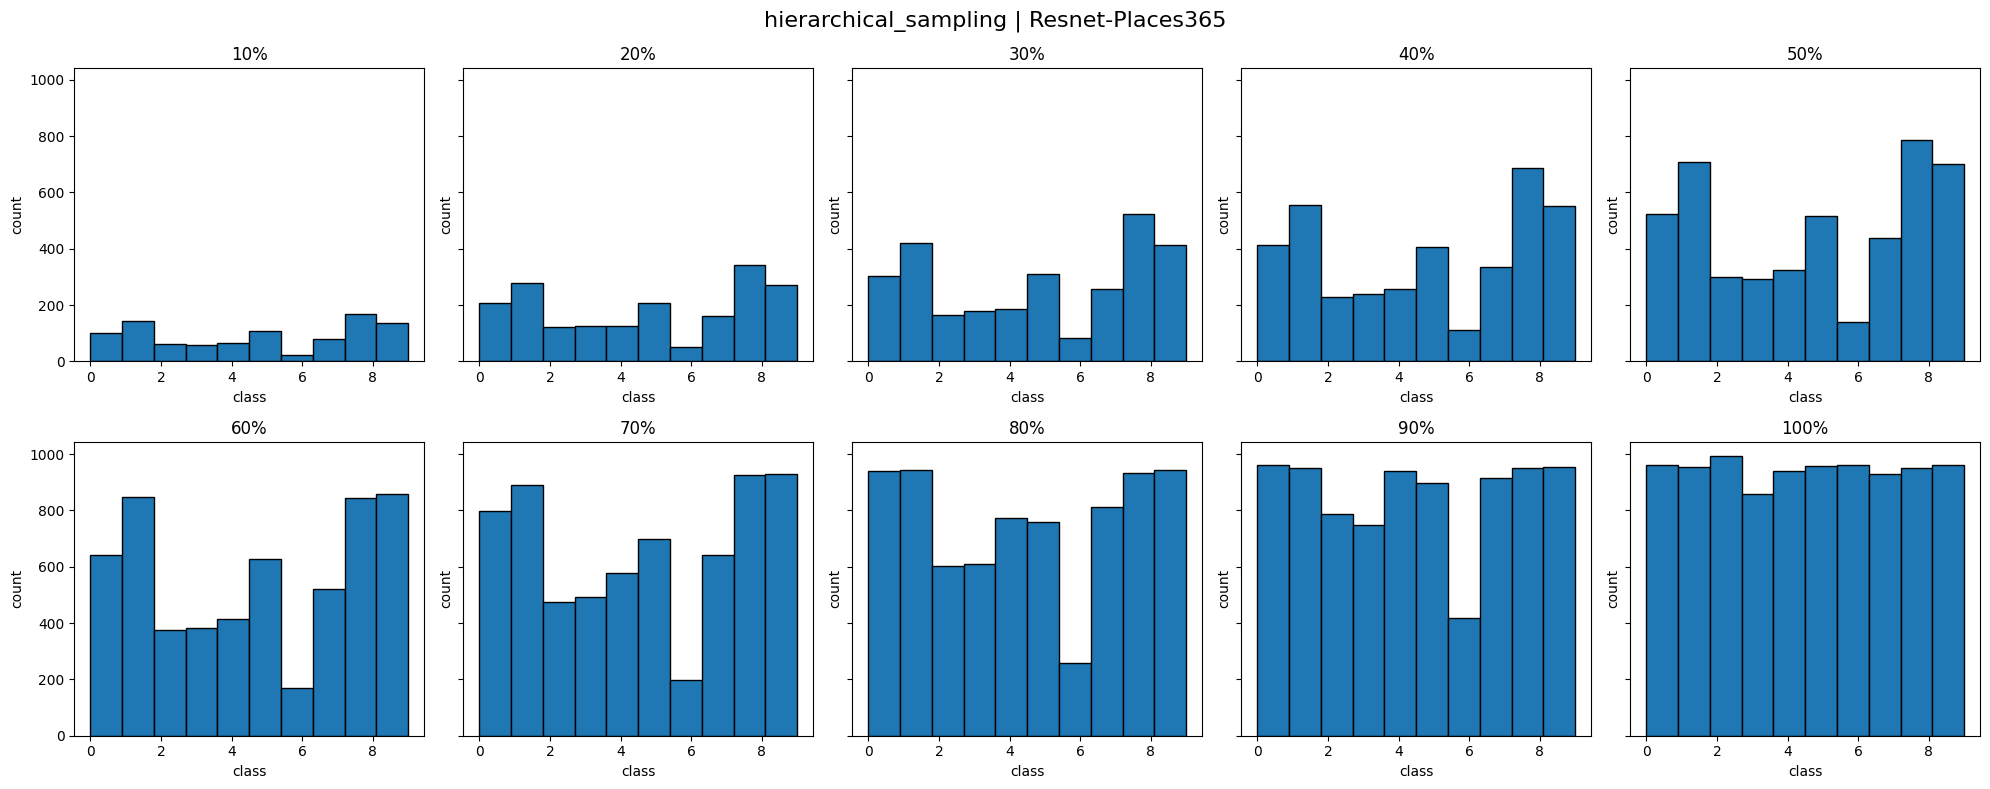

In [ ]:
percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for method in sampling_embedings["clustering_method"].unique():
    for emb in sampling_embedings["embedings"].unique():
        mask = (sampling_embedings["clustering_method"] == method) & (sampling_embedings["embedings"] == emb)
        rows = sampling_embedings[mask].reset_index(drop=True)

        fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=True)
        fig.suptitle(f"{method} | {emb}", fontsize=16)
        axes = axes.flatten()

        for i, (_, row) in enumerate(rows.iterrows()):
            ds = row["subset"]
            if isinstance(ds, Subset):
                labels = [ds.dataset.targets[j] for j in ds.indices]
            else:
                labels = ds.targets

            axes[i].hist(labels, bins=NUM_CLASSES, edgecolor="black")
            axes[i].set_title(f"{percentages[i]*100:.0f}%")
            axes[i].set_xlabel("class")
            axes[i].set_ylabel("count")

        plt.tight_layout()
        plt.show()

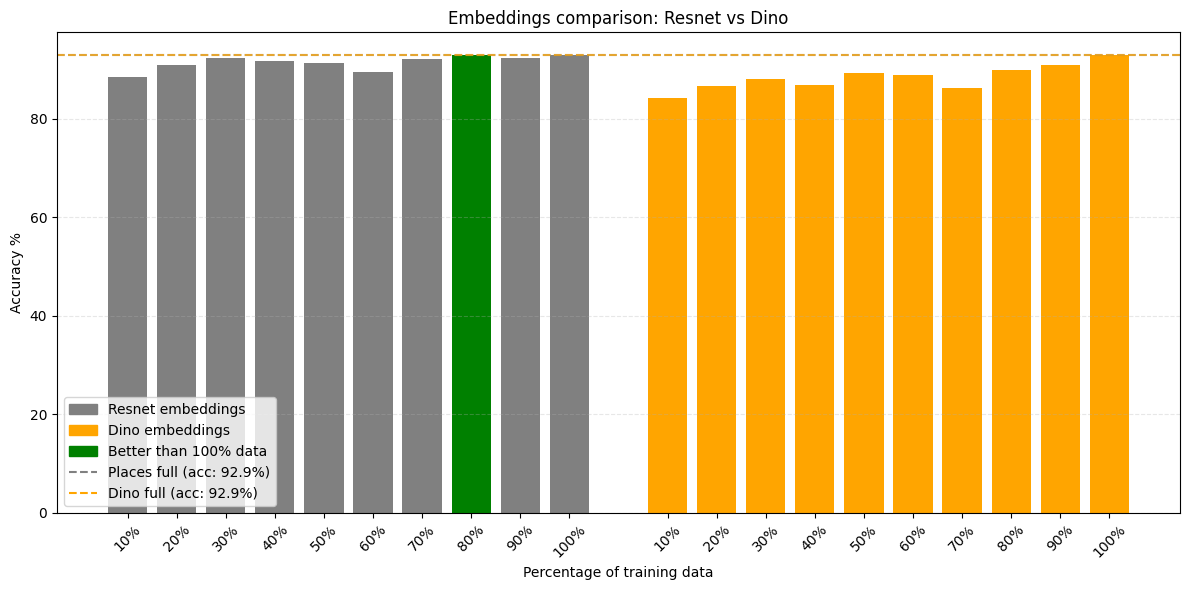

In [ ]:
# plt.figure(figsize=(12, 6))

# places = results_embedings[results_embedings["embedings"] == "Resnet-Places365"]
# dino = results_embedings[results_embedings["embedings"] == "Dino"]

# n = len(percentages)
# x_places = np.arange(n)
# x_dino = np.arange(n + 1, 2 * n + 1)

# places_full = places["accuracy"].values[-1]
# dino_full = dino["accuracy"].values[-1]

# places_colors = ['green' if a > places_full else 'gray' for a in places["accuracy"].values]
# dino_colors = ['green' if a > dino_full else 'orange' for a in dino["accuracy"].values]

# plt.bar(x_places, places["accuracy"].values, color=places_colors)
# plt.bar(x_dino, dino["accuracy"].values, color=dino_colors)

# plt.axhline(y=places_full, linestyle='--', color='gray', alpha=0.7)
# plt.axhline(y=dino_full, linestyle='--', color='orange', alpha=0.7)

# legend_handles = [
#     Patch(color='gray', label='Resnet embeddings'),
#     Patch(color='orange', label='Dino embeddings'),
#     Patch(color='green', label='Better than 100% data'),
#     Line2D([0], [0], linestyle='--', color='gray', label=f'Places full (acc: {places_full:.1f}%)'),
#     Line2D([0], [0], linestyle='--', color='orange', label=f'Dino full (acc: {dino_full:.1f}%)'),
# ]
# plt.legend(handles=legend_handles)

# all_x = np.concatenate([x_places, x_dino])
# all_labels = list(places["percentage"].values) + list(dino["percentage"].values)
# plt.xticks(all_x, all_labels, rotation=45)

# plt.xlabel('Percentage of training data')
# plt.ylabel('Accuracy %')
# plt.title('Embeddings comparison: Resnet vs Dino')
# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()

# plt.show()